In [3]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Src.config import ANALYZED_DATA

load_dotenv()

df = pd.read_csv(ANALYZED_DATA)

## tokenizing

In [2]:
def tokenize(text):
    if pd.isna(text) or text == "":
        return []
    tokens = text.split()
    return tokens
df['Cleaned_Text_tokenized'] = df['clean_text'].apply(tokenize)

In [3]:
df.Cleaned_Text_tokenized.head()

0    [surat, edar, ditjen, kemenag, nomor, tahun, a...
1    [anak, aceh, penuh, gizi, indonesia, indonesia...
2    [tengah, januari, sekarang, list, seko, masyar...
3                                               [agen]
4    [bisnis, gera, sosial, peduli, sehat, anakanak...
Name: Cleaned_Text_tokenized, dtype: object

## Vectorisasi (BoW / TF-IDF)

In [ ]:
df[["clean_text", "lang"]].head()

,aba,abah,abai,abalabal,abang,abc,abdi,abdul,abdurrahman,abi,...,zero,zolim,zona,zonauang,zonk,zoom,zul,zulfa,zulhas,zulkifli
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Topic Modeling dengan LDA

Bagian ini memakai kolom `clean_text` dari `mbg_analyzed.csv`, lalu membangun corpus, melatih beberapa model LDA, memilih jumlah topik terbaik dari coherence score, dan menyimpan hasilnya.

In [4]:
def tokenize_text(text):
    if pd.isna(text):
        return []

    tokens = str(text).lower().split()
    cleaned_tokens = []
    for token in tokens:
        token = token.strip(".,!?;:\"'()[]{}<>|/\\")
        if token:
            cleaned_tokens.append(token)

    return cleaned_tokens


df = df[df["lang"].eq("in")].copy()
df = df[df["clean_text"].notna()].copy()
df["tokens"] = df["clean_text"].apply(tokenize_text)
df["token_count"] = df["tokens"].apply(len)
df = df[df["token_count"] > 0].copy()

df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,surat edar ditjen kemenag nomor tahun atur pan...,"[surat, edar, ditjen, kemenag, nomor, tahun, a..."
1,anak aceh penuh gizi indonesia indonesiaemas a...,"[anak, aceh, penuh, gizi, indonesia, indonesia..."
2,tengah januari sekarang list seko masyarakat m...,"[tengah, januari, sekarang, list, seko, masyar..."
3,agen,[agen]
4,bisnis gera sosial peduli sehat anakanak perca...,"[bisnis, gera, sosial, peduli, sehat, anakanak..."


In [5]:
def build_dictionary_and_corpus(texts, no_below=5, no_above=0.5):
    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(text) for text in texts]
    return dictionary, corpus


def train_lda_models(dictionary, corpus, texts, topic_range=range(2, 13), passes=8):
    results = []
    models = {}

    for num_topics in topic_range:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=passes,
            iterations=100,
            alpha="auto",
            eta="auto",
            chunksize=2000,
            eval_every=None,
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v",
        )

        coherence = coherence_model.get_coherence()
        perplexity = model.log_perplexity(corpus)

        results.append({
            "num_topics": num_topics,
            "passes": passes,
            "coherence": coherence,
            "perplexity": perplexity,
        })
        models[num_topics] = model
        print(f"k={num_topics} | passes={passes} | coherence={coherence:.4f} | perplexity={perplexity:.2f}")

    return pd.DataFrame(results), models


texts = df["tokens"].tolist()
dictionary, corpus = build_dictionary_and_corpus(texts, no_below=5, no_above=0.5)
df_lda_results, lda_models = train_lda_models(dictionary, corpus, texts)

k=2 | passes=8 | coherence=0.5730 | perplexity=-6.98
k=3 | passes=8 | coherence=0.5784 | perplexity=-6.98
k=4 | passes=8 | coherence=0.5676 | perplexity=-7.03
k=5 | passes=8 | coherence=0.5651 | perplexity=-7.07
k=6 | passes=8 | coherence=0.5102 | perplexity=-7.10
k=7 | passes=8 | coherence=0.5700 | perplexity=-7.12
k=8 | passes=8 | coherence=0.5557 | perplexity=-7.15
k=9 | passes=8 | coherence=0.4791 | perplexity=-7.15
k=10 | passes=8 | coherence=0.4774 | perplexity=-7.17
k=11 | passes=8 | coherence=0.5163 | perplexity=-7.23
k=12 | passes=8 | coherence=0.5053 | perplexity=-7.37


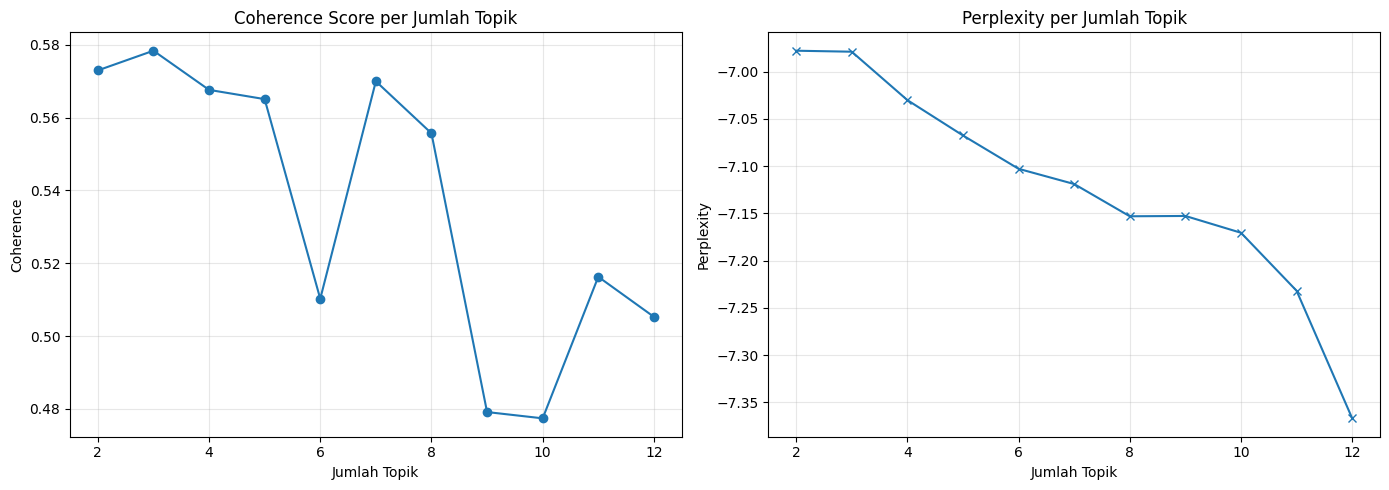

Best k: 3
num_topics    3.000000
passes        8.000000
coherence     0.578397
perplexity   -6.978877
Name: 1, dtype: float64


In [6]:
if not df_lda_results.empty:
    best_row = df_lda_results.sort_values("coherence", ascending=False).iloc[0]
    best_k = int(best_row["num_topics"])
    best_model = lda_models[best_k]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(df_lda_results["num_topics"], df_lda_results["coherence"], marker="o")
    axes[0].set_title("Coherence Score per Jumlah Topik")
    axes[0].set_xlabel("Jumlah Topik")
    axes[0].set_ylabel("Coherence")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_lda_results["num_topics"], df_lda_results["perplexity"], marker="x")
    axes[1].set_title("Perplexity per Jumlah Topik")
    axes[1].set_xlabel("Jumlah Topik")
    axes[1].set_ylabel("Perplexity")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Best k: {best_k}")
    print(best_row)
else:
    best_model = None
    best_k = None

In [7]:
def extract_topic_info(lda_model, num_words=12):
    rows = []
    raw_topics = lda_model.show_topics(num_topics=-1, num_words=num_words, formatted=False)

    for topic_id, word_list in raw_topics:
        rows.append({
            "topic_id": topic_id + 1,
            "keywords": ", ".join([word for word, prob in word_list]),
            "probability_formula": " + ".join([f"{prob:.4f}*\"{word}\"" for word, prob in word_list]),
        })

    return pd.DataFrame(rows)


def get_document_topic_matrix(lda_model, corpus, num_topics):
    topic_matrix = []
    dominant_topics = []

    for doc in corpus:
        doc_topics = lda_model.get_document_topics(doc, minimum_probability=0)
        vector = [0.0] * num_topics

        for topic_id, prob in doc_topics:
            vector[topic_id] = prob

        topic_matrix.append(vector)

        dominant_topic_id, dominant_prob = max(doc_topics, key=lambda item: item[1])
        dominant_topics.append((dominant_topic_id + 1, dominant_prob))

    return np.array(topic_matrix), dominant_topics


if best_model is not None:
    df_topics = extract_topic_info(best_model, num_words=12)
    display(df_topics)

    topic_matrix, dominant_topics = get_document_topic_matrix(best_model, corpus, best_k)

    for topic_index in range(best_k):
        df[f"topic_{topic_index + 1}"] = topic_matrix[:, topic_index]

    df["dominant_topic"] = [topic for topic, prob in dominant_topics]
    df["dominant_topic_prob"] = [prob for topic, prob in dominant_topics]

    topic_output_dir = Path("../../Output/TopicModeling")
    topic_output_dir.mkdir(parents=True, exist_ok=True)

    df_lda_results.to_csv(topic_output_dir / "mbg_lda_tuning_results.csv", index=False)
    df_topics.to_csv(topic_output_dir / f"mbg_lda_topics_k{best_k}.csv", index=False)
    df.to_csv(topic_output_dir / f"mbg_lda_documents_k{best_k}.csv", index=False)

    print(f"Saved outputs to: {topic_output_dir.resolve()}")

,topic_id,keywords,probability_formula
0,1,"bgn, racun, menu, siswa, makan, dapur, laksana...","0.0131*""bgn"" + 0.0125*""racun"" + 0.0112*""menu"" ..."
1,2,"indonesia, gizi, dukung, sehat, anak, penuh, m...","0.0418*""indonesia"" + 0.0346*""gizi"" + 0.0325*""d..."
2,3,"anak, sekolah, racun, lebih, makan, anggar, bu...","0.0128*""anak"" + 0.0116*""sekolah"" + 0.0115*""rac..."


Saved outputs to: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Competition/SatriaData/2026/internalTus/Output/TopicModeling


## Bigram, Trigram, dan Label Manual

Bagian ini menambah representasi bigram dan trigram, memilih model terbaik dari masing-masing representasi, lalu memberi label topik secara manual sebelum dihitung distribusi topiknya per minggu dan per frame.

In [8]:
import ast
from gensim.models.phrases import Phrases, Phraser


def build_phrase_texts(texts, phrase_type="bigram", min_count=5, threshold=10):
    if phrase_type == "bigram":
        phrase_model = Phrases(texts, min_count=min_count, threshold=threshold)
        phrase_phraser = Phraser(phrase_model)
        phrase_texts = [phrase_phraser[doc] for doc in texts]
        return phrase_texts

    if phrase_type == "trigram":
        bigram_model = Phrases(texts, min_count=min_count, threshold=threshold)
        bigram_phraser = Phraser(bigram_model)
        bigram_texts = [bigram_phraser[doc] for doc in texts]

        trigram_model = Phrases(bigram_texts, min_count=min_count, threshold=threshold)
        trigram_phraser = Phraser(trigram_model)
        trigram_texts = [trigram_phraser[doc] for doc in bigram_texts]
        return trigram_texts

    raise ValueError("phrase_type must be 'bigram' or 'trigram'")


def train_variant_lda(texts_variant, label, no_below=5, no_above=0.5, topic_range=range(2, 13), passes=8):
    dictionary, corpus = build_dictionary_and_corpus(texts_variant, no_below=no_below, no_above=no_above)
    results, models = train_lda_models(dictionary, corpus, texts_variant, topic_range=topic_range, passes=passes)
    results = results.assign(representation=label)
    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "results": results,
        "models": models,
        "texts": texts_variant,
    }


base_texts = df["tokens"].tolist()
df["tokens_bigram"] = build_phrase_texts(base_texts, phrase_type="bigram")
df["tokens_trigram"] = build_phrase_texts(base_texts, phrase_type="trigram")

representation_bank = {
    "bigram": train_variant_lda(df["tokens_bigram"].tolist(), "bigram"),
    "trigram": train_variant_lda(df["tokens_trigram"].tolist(), "trigram"),
}

combined_results = pd.concat(
    [
        df_lda_results.assign(representation="unigram"),
        representation_bank["bigram"]["results"],
        representation_bank["trigram"]["results"],
    ],
    ignore_index=True,
)

df_rep_best = combined_results.loc[
    combined_results.groupby("representation")["coherence"].idxmax()
].sort_values("coherence", ascending=False).reset_index(drop=True)

display(df_rep_best)

combined_results.to_csv(topic_output_dir / "mbg_lda_all_representations_tuning.csv", index=False)

k=2 | passes=8 | coherence=0.4599 | perplexity=-7.32
k=3 | passes=8 | coherence=0.4308 | perplexity=-7.27
k=4 | passes=8 | coherence=0.4911 | perplexity=-7.32
k=5 | passes=8 | coherence=0.4531 | perplexity=-7.36
k=6 | passes=8 | coherence=0.4431 | perplexity=-7.41
k=7 | passes=8 | coherence=0.3845 | perplexity=-7.42
k=8 | passes=8 | coherence=0.4506 | perplexity=-7.45
k=9 | passes=8 | coherence=0.4252 | perplexity=-7.47
k=10 | passes=8 | coherence=0.4446 | perplexity=-7.51
k=11 | passes=8 | coherence=0.4122 | perplexity=-7.51
k=12 | passes=8 | coherence=0.4233 | perplexity=-7.73
k=2 | passes=8 | coherence=0.4820 | perplexity=-7.31
k=3 | passes=8 | coherence=0.5113 | perplexity=-7.34
k=4 | passes=8 | coherence=0.4931 | perplexity=-7.41
k=5 | passes=8 | coherence=0.4808 | perplexity=-7.44
k=6 | passes=8 | coherence=0.4757 | perplexity=-7.47
k=7 | passes=8 | coherence=0.4258 | perplexity=-7.49
k=8 | passes=8 | coherence=0.4446 | perplexity=-7.52
k=9 | passes=8 | coherence=0.4818 | perplex

,num_topics,passes,coherence,perplexity,representation
0,3,8,0.578397,-6.978877,unigram
1,3,8,0.511319,-7.336238,trigram
2,4,8,0.491071,-7.323008,bigram


In [12]:
def get_best_model_info(rep_name):
    if rep_name == "unigram":
        return best_row, best_k, best_model, texts, corpus

    rep_row = df_rep_best[df_rep_best["representation"] == rep_name].iloc[0]
    rep_best_k = int(rep_row["num_topics"])
    rep_best_model = representation_bank[rep_name]["models"][rep_best_k]
    rep_texts = representation_bank[rep_name]["texts"]
    rep_corpus = representation_bank[rep_name]["corpus"]
    return rep_row, rep_best_k, rep_best_model, rep_texts, rep_corpus


chosen_representation = df_rep_best.iloc[0]["representation"]
chosen_row, chosen_k, chosen_model, chosen_texts, chosen_corpus = get_best_model_info(chosen_representation)
chosen_topics = extract_topic_info(chosen_model, num_words=12)

manual_label_suggestions = {
    1: "Operasional dan Implementasi MBG",
    2: "Dukungan Gizi dan Nasionalisme",
    3: "Kritik Anggaran dan Implementasi",
}
chosen_topics["manual_label"] = chosen_topics["topic_id"].map(manual_label_suggestions)
chosen_topics["manual_label"] = chosen_topics["manual_label"].fillna(
    chosen_topics["topic_id"].apply(lambda topic_id: f"Topik {topic_id}")
)

print(f"Chosen representation: {chosen_representation}")
print(f"Chosen k: {chosen_k}")
display(chosen_topics)

label_map = dict(zip(chosen_topics["topic_id"], chosen_topics["manual_label"]))

topic_matrix, dominant_topics = get_document_topic_matrix(chosen_model, chosen_corpus, chosen_k)
df["dominant_topic_selected"] = [topic for topic, prob in dominant_topics]
df["dominant_topic_prob_selected"] = [prob for topic, prob in dominant_topics]
df["topic_label_selected"] = df["dominant_topic_selected"].map(label_map)

df["frame_utama_clean"] = df.get("frame_utama", pd.Series(index=df.index, dtype="object")).fillna("tidak_terklasifikasi")

def parse_frames(value):
    if pd.isna(value) or value == "":
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else [parsed]
        except Exception:
            return [value]
    return []


df["all_frames_list"] = df.get("all_frames", pd.Series([[] for _ in range(len(df))], index=df.index)).apply(parse_frames)

print(df[["topic_label_selected", "frame_utama_clean"]].head())

Chosen representation: unigram
Chosen k: 3


,topic_id,keywords,probability_formula,manual_label
0,1,"bgn, racun, menu, siswa, makan, dapur, laksana...","0.0131*""bgn"" + 0.0125*""racun"" + 0.0112*""menu"" ...",Operasional dan Implementasi MBG
1,2,"indonesia, gizi, dukung, sehat, anak, penuh, m...","0.0418*""indonesia"" + 0.0346*""gizi"" + 0.0325*""d...",Dukungan Gizi dan Nasionalisme
2,3,"anak, sekolah, racun, lebih, makan, anggar, bu...","0.0128*""anak"" + 0.0116*""sekolah"" + 0.0115*""rac...",Kritik Anggaran dan Implementasi


               topic_label_selected       frame_utama_clean
0  Operasional dan Implementasi MBG  kebijakan_implementasi
1    Dukungan Gizi dan Nasionalisme          gizi_kesehatan
2  Kritik Anggaran dan Implementasi    tidak_terklasifikasi
3  Kritik Anggaran dan Implementasi    tidak_terklasifikasi
4    Dukungan Gizi dan Nasionalisme                 ekonomi


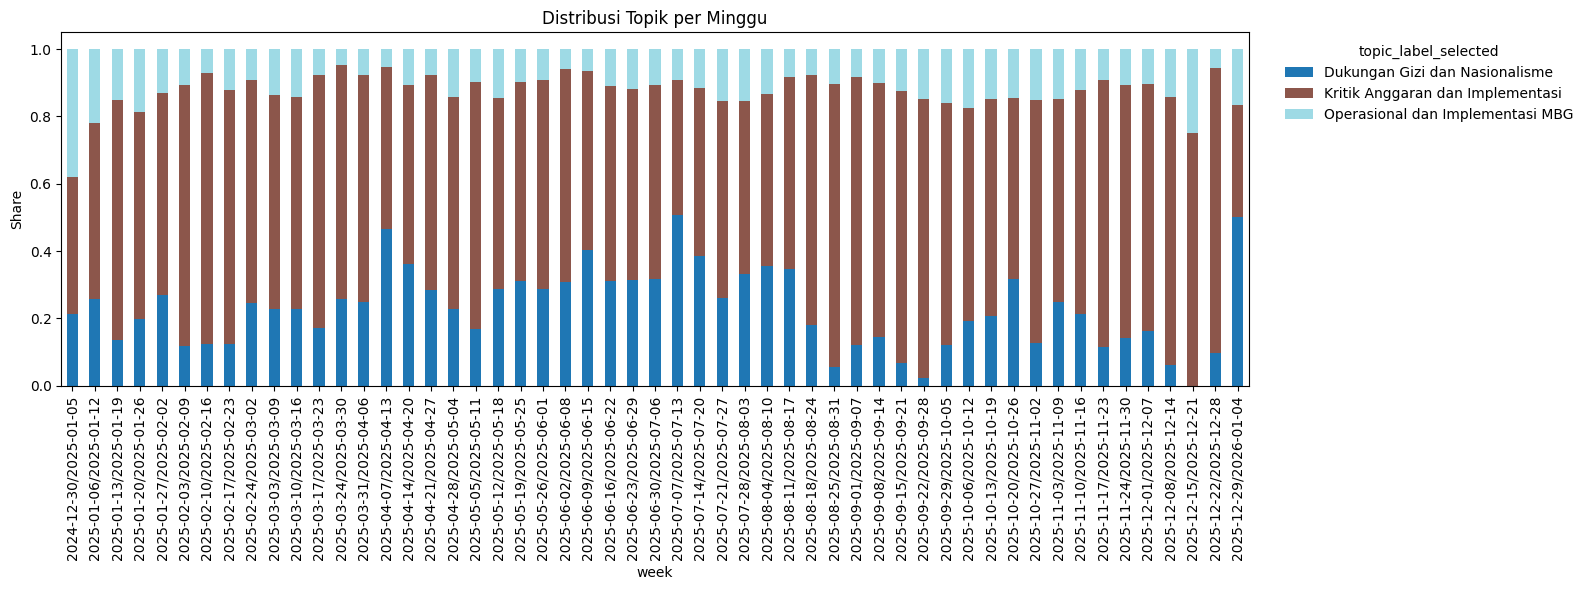

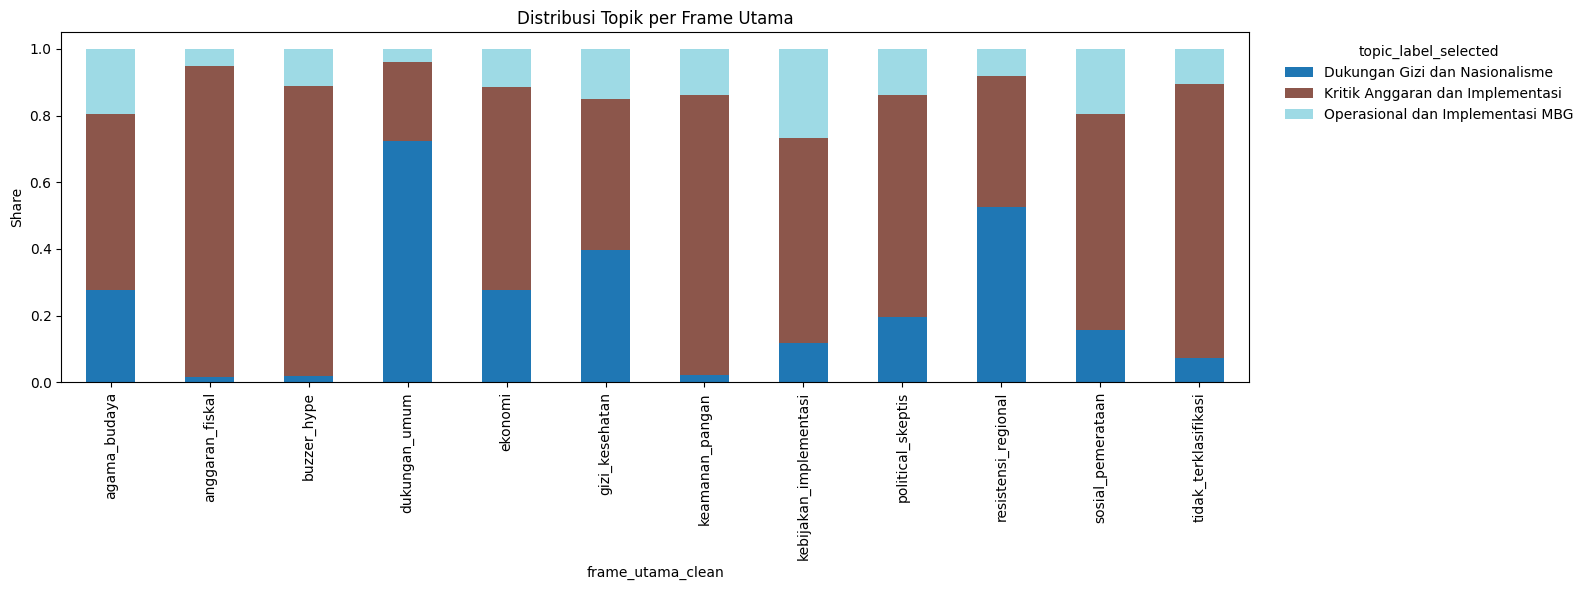

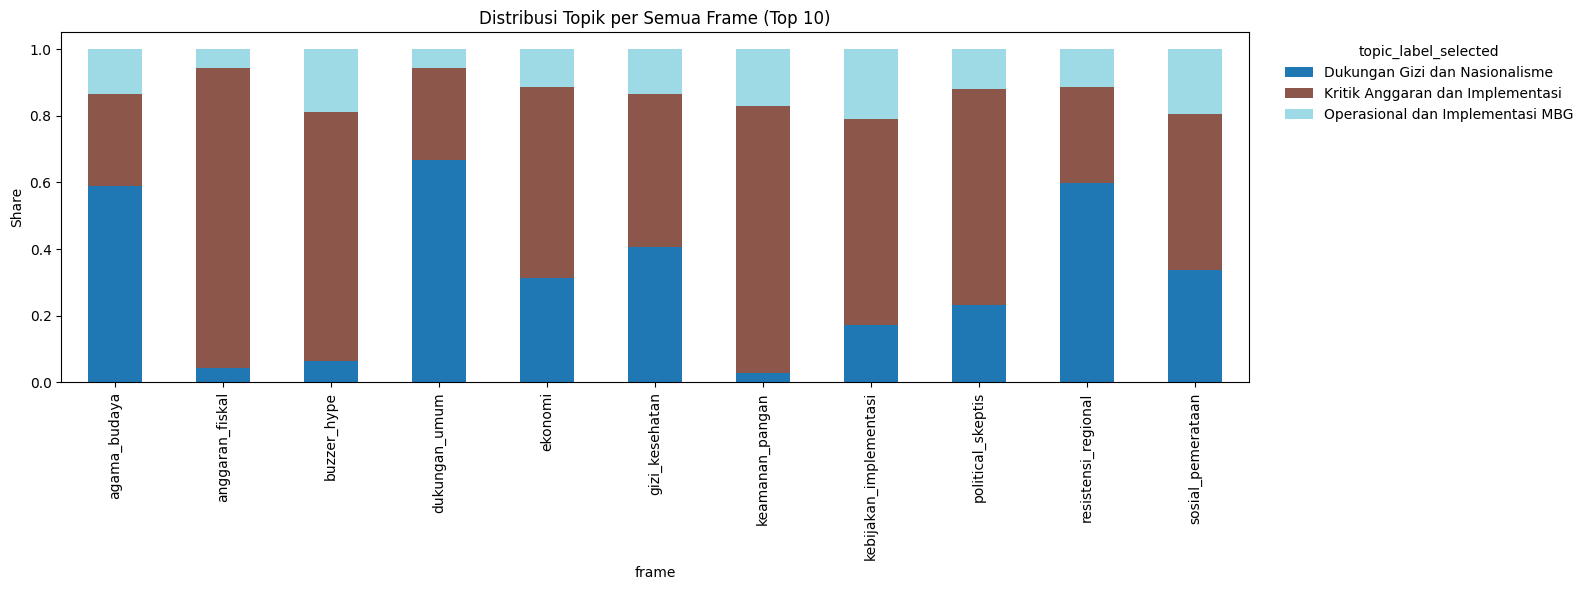

/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_52687/3270091737.py:59: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at_dt"].dt.to_period("M").astype(str)


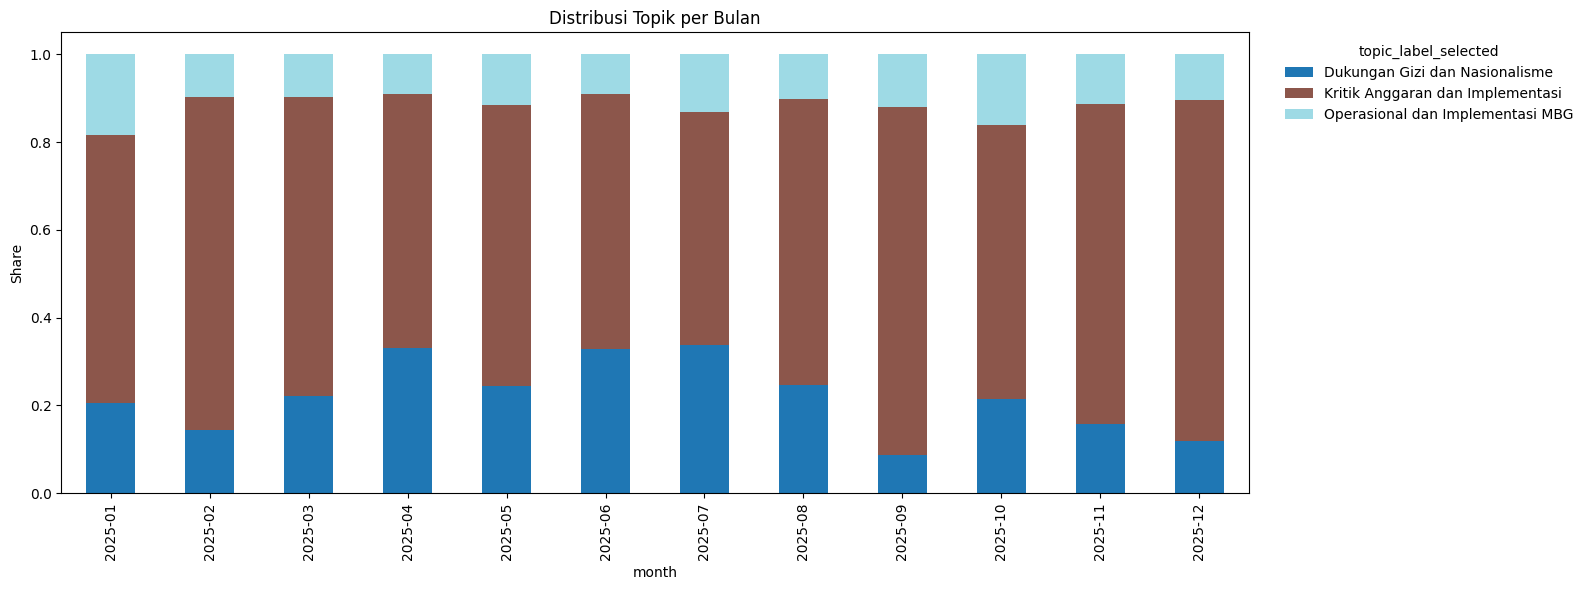

Saved labeled outputs to: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Competition/SatriaData/2026/internalTus/Output/TopicModeling


In [13]:
def plot_topic_distribution_over_time(df_input, topic_col, time_col, title, top_n=None):
    plot_df = df_input[[time_col, topic_col]].dropna().copy()
    plot_df[time_col] = plot_df[time_col].astype(str)

    counts = plot_df.groupby([time_col, topic_col]).size().reset_index(name="count")
    totals = counts.groupby(time_col)["count"].transform("sum")
    counts["share"] = counts["count"] / totals

    if top_n is not None:
        top_topics = (
            counts.groupby(topic_col)["count"].sum().sort_values(ascending=False).head(top_n).index
        )
        counts = counts[counts[topic_col].isin(top_topics)].copy()

    pivot = counts.pivot_table(index=time_col, columns=topic_col, values="share", fill_value=0)
    pivot = pivot.sort_index()

    ax = pivot.plot(kind="bar", stacked=True, figsize=(16, 6), colormap="tab20")
    ax.set_title(title)
    ax.set_xlabel(time_col)
    ax.set_ylabel("Share")
    ax.legend(title=topic_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    return counts, pivot


weekly_counts, weekly_pivot = plot_topic_distribution_over_time(
    df, "topic_label_selected", "week", "Distribusi Topik per Minggu", top_n=None
)

frameutama_counts, frameutama_pivot = plot_topic_distribution_over_time(
    df,
    "topic_label_selected",
    "frame_utama_clean",
    "Distribusi Topik per Frame Utama",
    top_n=None,
)

frame_counts = (
    df.explode("all_frames_list")
      .rename(columns={"all_frames_list": "frame"})
      .dropna(subset=["frame"])
)
frame_counts["frame"] = frame_counts["frame"].astype(str).str.strip()
frame_counts = frame_counts[frame_counts["frame"] != ""]

frame_topic_counts, frame_topic_pivot = plot_topic_distribution_over_time(
    frame_counts,
    "topic_label_selected",
    "frame",
    "Distribusi Topik per Semua Frame (Top 10)",
    top_n=10,
)

if "created_at_dt" in df.columns:
    df["created_at_dt"] = pd.to_datetime(df["created_at_dt"], errors="coerce")
    df["month"] = df["created_at_dt"].dt.to_period("M").astype(str)
    month_counts, month_pivot = plot_topic_distribution_over_time(
        df,
        "topic_label_selected",
        "month",
        "Distribusi Topik per Bulan",
        top_n=None,
    )
else:
    month_counts, month_pivot = None, None

output_dir = Path("../../Output/TopicModeling")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / f"mbg_lda_documents_{chosen_representation}_k{chosen_k}_labeled.csv", index=False)
weekly_counts.to_csv(output_dir / f"mbg_lda_weekly_distribution_{chosen_representation}_k{chosen_k}.csv", index=False)
frameutama_counts.to_csv(output_dir / f"mbg_lda_frameutama_distribution_{chosen_representation}_k{chosen_k}.csv", index=False)
frame_topic_counts.to_csv(output_dir / f"mbg_lda_frame_distribution_{chosen_representation}_k{chosen_k}.csv", index=False)
if month_counts is not None:
    month_counts.to_csv(output_dir / f"mbg_lda_monthly_distribution_{chosen_representation}_k{chosen_k}.csv", index=False)

print(f"Saved labeled outputs to: {output_dir.resolve()}")